In [1]:
# Cell 1 - Imports and load Random Forest test prediction files

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

rf_model_1_path = CLEAN_DIR / "gdp_random_forest_model_1_test_predictions.csv"
rf_model_2_path = CLEAN_DIR / "gdp_random_forest_model_2_test_predictions.csv"
rf_model_3_path = CLEAN_DIR / "gdp_random_forest_model_3_test_predictions.csv"

print("RF Model 1 exists:", rf_model_1_path.exists())
print("RF Model 2 exists:", rf_model_2_path.exists())
print("RF Model 3 exists:", rf_model_3_path.exists())

rf_model_1_df = pd.read_csv(rf_model_1_path)
rf_model_2_df = pd.read_csv(rf_model_2_path)
rf_model_3_df = pd.read_csv(rf_model_3_path)

print("RF Model 1 shape:", rf_model_1_df.shape)
print("RF Model 2 shape:", rf_model_2_df.shape)
print("RF Model 3 shape:", rf_model_3_df.shape)

RF Model 1 exists: True
RF Model 2 exists: True
RF Model 3 exists: True
RF Model 1 shape: (1042, 22)
RF Model 2 shape: (813, 25)
RF Model 3 shape: (813, 28)


In [2]:
# Cell 2 - Keep only common Random Forest test sample

join_cols = ["country_code", "feature_year", "target_year"]

rf1 = rf_model_1_df[
    join_cols + ["country_name", "wb_region", "actual_gdp_next_year", "predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "rf_pred_model_1"}
)

rf2 = rf_model_2_df[
    join_cols + ["predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "rf_pred_model_2"}
)

rf3 = rf_model_3_df[
    join_cols + ["predicted_gdp_next_year"]
].copy().rename(
    columns={"predicted_gdp_next_year": "rf_pred_model_3"}
)

rf_common_test_df = (
    rf1.merge(
        rf2[join_cols + ["rf_pred_model_2"]],
        on=join_cols,
        how="inner"
    )
    .merge(
        rf3[join_cols + ["rf_pred_model_3"]],
        on=join_cols,
        how="inner"
    )
)

print("RF common test rows:", rf_common_test_df.shape[0])
print("Countries:", rf_common_test_df["country_code"].nunique())
print("Target years:", int(rf_common_test_df["target_year"].min()), "-", int(rf_common_test_df["target_year"].max()))

display(rf_common_test_df.head())

RF common test rows: 813
Countries: 167
Target years: 2019 - 2023


,country_code,feature_year,target_year,country_name,wb_region,actual_gdp_next_year,rf_pred_model_1,rf_pred_model_2,rf_pred_model_3
0,AFG,2018,2019,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",496.6025,530.8640,516.4590,515.2002
1,AFG,2019,2020,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",510.7871,517.7142,525.1832,520.5579
2,AFG,2020,2021,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",356.4962,532.0590,530.6866,523.8374
3,AFG,2021,2022,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",357.2612,386.0626,419.3157,413.6020
4,AFG,2022,2023,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",413.7579,382.4137,439.7731,428.7521


In [3]:
# Cell 3 - Build yearly mean actual vs predicted for Random Forest

rf_yearly_compare_df = (
    rf_common_test_df.groupby("target_year", as_index=False)
    .agg(
        n_obs=("actual_gdp_next_year", "size"),
        actual_gdp=("actual_gdp_next_year", "mean"),
        rf_model_1_pred=("rf_pred_model_1", "mean"),
        rf_model_2_pred=("rf_pred_model_2", "mean"),
        rf_model_3_pred=("rf_pred_model_3", "mean"),
    )
    .sort_values("target_year")
    .reset_index(drop=True)
)

display(rf_yearly_compare_df)

,target_year,n_obs,actual_gdp,rf_model_1_pred,rf_model_2_pred,rf_model_3_pred
0,2019,166,"15,698.9605","16,325.6440","16,293.8758","16,232.8993"
1,2020,166,"14,549.3612","16,305.0968","16,152.4993","16,113.4938"
2,2021,162,"17,155.0981","15,118.8032","15,080.4178","15,039.9489"
3,2022,160,"18,048.6179","17,221.4441","17,062.4061","17,070.2421"
4,2023,159,"18,914.0876","18,171.5003","17,719.6101","17,775.7104"


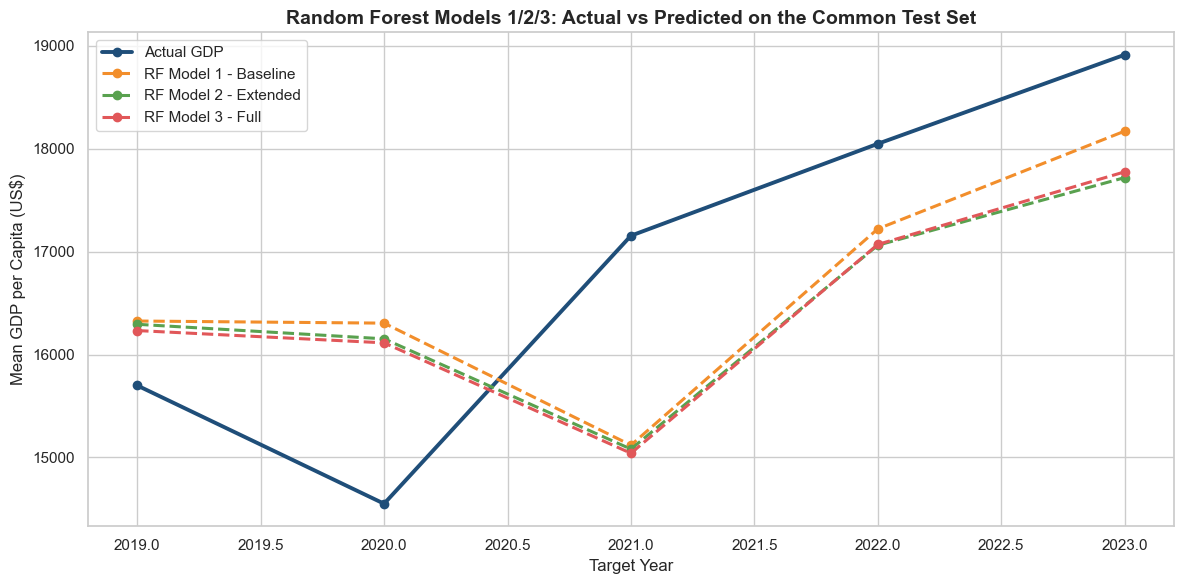

In [4]:
# Cell 4 - Line chart for Random Forest Model 1/2/3

plt.figure(figsize=(12, 6))

plt.plot(
    rf_yearly_compare_df["target_year"],
    rf_yearly_compare_df["actual_gdp"],
    marker="o",
    linewidth=2.8,
    color="#1f4e79",
    label="Actual GDP"
)

plt.plot(
    rf_yearly_compare_df["target_year"],
    rf_yearly_compare_df["rf_model_1_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#f28e2b",
    label="RF Model 1 - Baseline"
)

plt.plot(
    rf_yearly_compare_df["target_year"],
    rf_yearly_compare_df["rf_model_2_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#59a14f",
    label="RF Model 2 - Extended"
)

plt.plot(
    rf_yearly_compare_df["target_year"],
    rf_yearly_compare_df["rf_model_3_pred"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    color="#e15759",
    label="RF Model 3 - Full"
)

plt.title("Random Forest Models 1/2/3: Actual vs Predicted on the Common Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Target Year")
plt.ylabel("Mean GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 - Save Random Forest compare table

rf_compare_save_path = CLEAN_DIR / "gdp_random_forest_models_1_2_3_test_linechart_common_sample.csv"
rf_yearly_compare_df.to_csv(rf_compare_save_path, index=False)
print("Saved to:", rf_compare_save_path)

Saved to: /Users/tonytony/Final Project/Data/Cleaned/gdp_random_forest_models_1_2_3_test_linechart_common_sample.csv
